# Notebook 01: ASL Citizen — EDA và chọn 10 lớp ứng viên
#
Mục tiêu: phân tích metadata, kiểm tra chất lượng split và xuất subset nhỏ để trích landmark/train ở notebook tiếp theo.
**Không tải dataset, không giải nén toàn bộ video và không train trong notebook này.** Chỉ metadata là bắt buộc;
phần xem video là tùy chọn, chỉ đọc video của các lớp đã chọn.
#
Trên Kaggle: **Add Input** dataset ASL Citizen có `train.csv`, `val.csv`, `test.csv`, rồi chạy từ trên xuống.
Không cần GPU hoặc Internet nếu dữ liệu và thư viện đã có sẵn. Nếu chỉ có một ZIP lớn, cần chuẩn bị riêng ba CSV;
notebook không đọc metadata nằm bên trong ZIP. Gắn dataset WLASL của notebook cũ sẽ không dùng được ở đây.
#
Nguồn: [Microsoft ASL Citizen](https://www.microsoft.com/en-us/research/project/asl-citizen/),
[split theo người ký](https://www.microsoft.com/en-us/research/project/asl-citizen/dataset-description/),
[bộ đọc metadata chính thức](https://github.com/microsoft/ASL-citizen-code/blob/main/I3D/aslcitizen_dataset.py).
Số lượng thực tế được tính từ CSV của bạn, không dùng số liệu cố định của bài báo.

## 1. Cấu hình
#
Để `SPLIT_DIR = None` để tìm bộ CSV trong `/kaggle/input`. Nếu có nhiều bộ, đặt đường dẫn thư mục chứa đúng ba CSV.
Chạy local: đặt `SPLIT_DIR` tới metadata đã tải và cài các thư viện trong `requirements.txt`.
`VIDEO_DIR` là thư mục gốc để ghép với cột tên video; chỉ cần đặt khi muốn kiểm tra/xem video.
#
Ngưỡng mặc định là **10 video train và 5 người ký train/lớp**, phục vụ lọc ứng viên chứ không bảo đảm độ chính xác.
`SELECTED_GLOSSES = []` chọn tự động; sau khi xem video có thể điền đúng 10 gloss để chọn thủ công.
Không thay đổi số lớp hoặc hạ ngưỡng tự động nếu không đủ dữ liệu.

In [11]:

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SPLIT_DIR = Path("/kaggle/input/datasets/abd0kamel/asl-citizen/ASL_Citizen/splits")
VIDEO_DIR = Path("/kaggle/input/datasets/abd0kamel/asl-citizen/ASL_Citizen/videos")

NUM_CLASSES = 10
MIN_TRAIN_VIDEOS = 10
MIN_TRAIN_SIGNERS = 5
SELECTED_GLOSSES = []
CHECK_VIDEOS = False
SAMPLES_PER_CLASS = 1
SEED = 42

OUTPUT_DIR = Path("/kaggle/working/asl_citizen_eda")

plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 20)

print("Thư mục splits tồn tại:", SPLIT_DIR.is_dir())
print("Thư mục videos tồn tại:", VIDEO_DIR.is_dir())

Thư mục splits tồn tại: True
Thư mục videos tồn tại: True


In [12]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import dispSPLIT_DIR = Path("/kaggle/input/datasets/abd0kamel/asl-citizen/ASL_Citizen/splits")
VIDEO_DIR = Path("/kaggle/input/datasets/abd0kamel/asl-citizen/ASL_Citizen/videos")R = None  # Ví dụ: Path("/kaggle/input/<dataset>/ASL_Citizen/videos")
NUM_CLASSES = 10
MIN_TRAIN_VIDEOS = 10
MIN_TRAIN_SIGNERS = 5
SELECTED_GLOSSES = []
CHECK_VIDEOS = False
SAMPLES_PER_CLASS = 1
SEED = 42
OUTPUT_DIR = (
    Path("/kaggle/working/asl_citizen_eda")
    if Path("/kaggle").exists()
    else Path("data/processed/asl_citizen_eda")
)
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 20)

SyntaxError: invalid syntax (3203271422.py, line 6)

## 2. Đọc và kiểm tra metadata
#
Hỗ trợ header gốc `Participant ID`, `Video file`, `Gloss` và tên chuẩn `signer_id`, `video_file`, `gloss`.
Giữ nguyên gloss (chỉ bỏ khoảng trắng đầu/cuối), người ký và split; không random split lại.
Thiếu cột/giá trị, split rỗng, đường dẫn video không an toàn hoặc split mâu thuẫn sẽ báo lỗi để sửa nguồn.

In [13]:
from pathlib import Path, PurePosixPath
from itertools import combinations
import json
import pandas as pd


def load_metadata(split_dir):
    frames = []
    for split in ("train", "val", "test"):
        path = Path(split_dir) / f"{split}.csv"
        raw = pd.read_csv(path, dtype="string", encoding="utf-8-sig")
        raw.columns = [
            name.strip().lower().replace("-", "_").replace(" ", "_")
            for name in raw.columns
        ]
        raw = raw.rename(columns={"participant_id": "signer_id"})
        required = ["signer_id", "video_file", "gloss"]
        if raw.columns.duplicated().any():
            raise ValueError(f"{path}: tên cột bị trùng sau chuẩn hóa.")
        missing = set(required) - set(raw.columns)
        if missing:
            raise ValueError(
                f"{path}: thiếu cột {sorted(missing)}. Có: {list(raw.columns)}"
            )
        if raw.empty:
            raise ValueError(f"{path}: split rỗng.")
        for column in required:
            raw[column] = raw[column].str.strip()
            invalid = raw[column].isna() | raw[column].eq("")
            if invalid.any():
                raise ValueError(
                    f"{path}: {column} thiếu giá trị ở dòng CSV {(raw.index[invalid] + 2).tolist()[:5]}"
                )
        if "split" in raw.columns and not raw["split"].eq(split).fillna(False).all():
            raise ValueError(f"{path}: cột split không khớp tên CSV.")
        raw["video_file"] = raw["video_file"].str.replace("\\", "/", regex=False)
        for filename in raw["video_file"]:
            relative = PurePosixPath(filename)
            if (
                relative.is_absolute()
                or ".." in relative.parts
                or ":" in filename
                or relative.suffix.lower() != ".mp4"
            ):
                raise ValueError(f"{path}: đường dẫn video không hợp lệ: {filename!r}")
        raw["video_id"] = raw["video_file"].map(lambda name: PurePosixPath(name).stem)
        raw["split"] = split
        frames.append(raw)
    return pd.concat(frames, ignore_index=True)


def audit_metadata(df):
    for key in ("video_file", "video_id"):
        repeated = df.loc[df[key].duplicated(keep=False), [key, "gloss", "split"]]
        if not repeated.empty:
            raise ValueError(
                f"Trùng video ({key}), cần sửa trước khi xuất:\n{repeated.head(10).to_string(index=False)}"
            )
    rows = []
    for left, right in combinations(("train", "val", "test"), 2):
        shared = set(df.loc[df["split"] == left, "signer_id"]) & set(
            df.loc[df["split"] == right, "signer_id"]
        )
        rows.append(
            {
                "splits": f"{left}/{right}",
                "shared_signers": len(shared),
                "signer_ids": ", ".join(sorted(shared)),
            }
        )
    overlap = pd.DataFrame(rows)
    if overlap["shared_signers"].any():
        raise ValueError(
            f"Data leakage: signer xuất hiện ở nhiều split:\n{overlap.to_string(index=False)}"
        )
    return overlap


def class_statistics(df):
    counts = pd.crosstab(df["gloss"], df["split"]).reindex(
        columns=["train", "val", "test"], fill_value=0
    )
    counts.columns.name = None
    training = df[df["split"] == "train"]
    counts["train_signers"] = (
        training.groupby("gloss")["signer_id"]
        .nunique()
        .reindex(counts.index, fill_value=0)
    )
    counts["total"] = counts[["train", "val", "test"]].sum(axis=1)
    return (
        counts.reset_index()
        .sort_values(
            ["train", "train_signers", "gloss"], ascending=[False, False, True]
        )
        .set_index("gloss")
    )


def select_subset(df, stats, num_classes, min_videos, min_signers, selected_glosses):
    if num_classes < 1 or min_videos < 1 or min_signers < 1:
        raise ValueError("Số lớp và ngưỡng train phải >= 1.")
    audit_metadata(df)
    eligible = stats[
        (stats["train"] >= min_videos) & (stats["train_signers"] >= min_signers)
    ]
    selected = (
        list(selected_glosses)
        if selected_glosses
        else eligible.head(num_classes).index.tolist()
    )
    if len(selected) != num_classes or len(set(selected)) != num_classes:
        raise ValueError(
            f"Cần đúng {num_classes} gloss khác nhau; có {len(eligible)} lớp đạt ngưỡng train. Kiểm tra bảng hoặc điều chỉnh cấu hình."
        )
    unknown = set(selected) - set(eligible.index)
    if unknown:
        raise ValueError(f"Gloss không có/không đạt ngưỡng train: {sorted(unknown)}")
    uncovered = stats.loc[selected, ["val", "test"]].eq(0).any(axis=1)
    if uncovered.any():
        raise ValueError(
            f"Lớp đã chọn thiếu mẫu val/test: {uncovered[uncovered].index.tolist()}. Kiểm tra bộ split nguồn."
        )
    labels = {gloss: index for index, gloss in enumerate(sorted(selected))}
    subset = df[df["gloss"].isin(labels)].copy()
    subset["class_id"] = subset["gloss"].map(labels)
    return subset, labels


def export_subset(subset, stats, labels, output_dir):
    audit_metadata(subset)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    for split in ("train", "val", "test"):
        subset[subset["split"] == split].to_csv(
            output_dir / f"{split}.csv", index=False
        )
    stats.to_csv(output_dir / "class_statistics.csv")
    selected = stats.loc[list(labels)].copy()
    selected.insert(0, "class_id", [labels[gloss] for gloss in selected.index])
    selected.to_csv(output_dir / "selected_classes.csv")
    (output_dir / "label_map.json").write_text(
        json.dumps(labels, ensure_ascii=False, indent=2), encoding="utf-8"
    )

In [14]:
if SPLIT_DIR is None:
    search_root = (
        Path("/kaggle/input")
        if Path("/kaggle/input").exists()
        else Path("data/raw/metadata")
    )
    candidates = sorted(
        {
            path.parent
            for path in search_root.rglob("train.csv")
            if (path.parent / "val.csv").is_file()
            and (path.parent / "test.csv").is_file()
        }
    )
    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Tìm thấy {len(candidates)} bộ train/val/test CSV trong {search_root}: {candidates}. "
            "Hãy Add Input ASL Citizen hoặc đặt SPLIT_DIR rõ ràng; không dùng data/splits CSV khung của repo."
        )
    SPLIT_DIR = candidates[0]
SPLIT_DIR = Path(SPLIT_DIR)
df = load_metadata(SPLIT_DIR)
print(f"Metadata: {SPLIT_DIR}")
print(
    f"Video: {len(df):,} | Gloss: {df['gloss'].nunique():,} | Signer: {df['signer_id'].nunique():,}"
)
display(df.head())
display(df.isna().sum().rename("missing_values").to_frame())

Metadata: /kaggle/input/datasets/abd0kamel/asl-citizen/ASL_Citizen/splits
Video: 83,399 | Gloss: 2,731 | Signer: 52


,signer_id,video_file,gloss,asl_lex_code,video_id,split
0,P1,15890366051589533-APPLE.mp4,APPLE,A_03_054,15890366051589533-APPLE,train
1,P1,35618482303951104-IMPOSSIBLE.mp4,IMPOSSIBLE,B_01_032,35618482303951104-IMPOSSIBLE,train
2,P1,6958143575951994-PARK.mp4,PARK,E_03_028,6958143575951994-PARK,train
3,P1,8006032738002744-SOCCER 2.mp4,SOCCER2,F_03_032,8006032738002744-SOCCER 2,train
4,P1,37542279833186454-STINK.mp4,STINK,H_01_064,37542279833186454-STINK,train


,missing_values
signer_id,0
video_file,0
gloss,0
asl_lex_code,183
video_id,0
split,0


## 3. Phân bố split và người ký — kiểm tra data leakage
#
Các trường bắt buộc đã được kiểm tra khi đọc. Hiển thị bản ghi video trùng trước khi audit;
audit **dừng notebook** nếu video hoặc người ký trùng giữa các split. Không tự xóa dòng hay chia lại tập.
Các cột phụ như ASL-LEX Code có thể thiếu; thống kê missing ở trên giúp nhận biết.

Số dòng liên quan video trùng: 0


,splits,shared_signers,signer_ids
0,train/val,0,
1,train/test,0,
2,val/test,0,


,videos,glosses,signers
split,,,
train,40154,2731,35
val,10304,2731,6
test,32941,2731,11


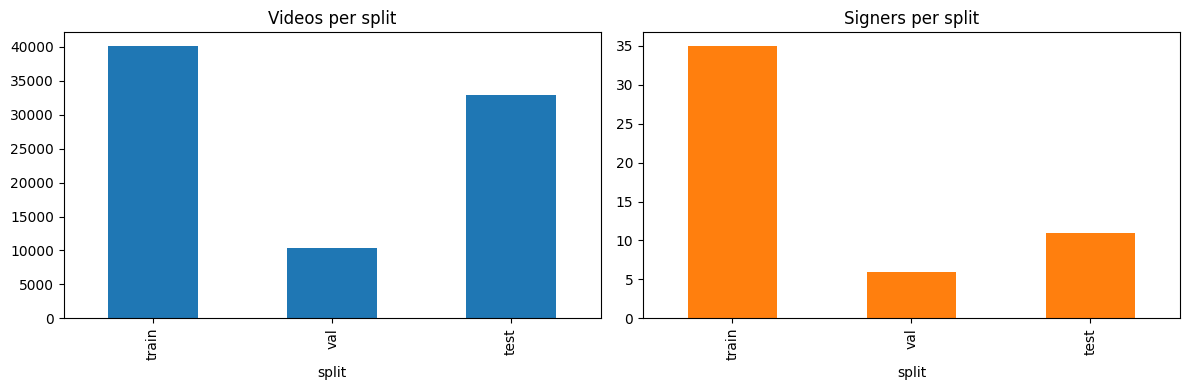

,split,signer_id,videos
0,test,P15,3000
1,test,P17,3000
2,test,P18,2998
3,test,P22,2997
4,test,P35,3004
5,test,P42,2996
6,test,P47,2966
7,test,P48,2999
8,test,P49,3000
9,test,P6,2993


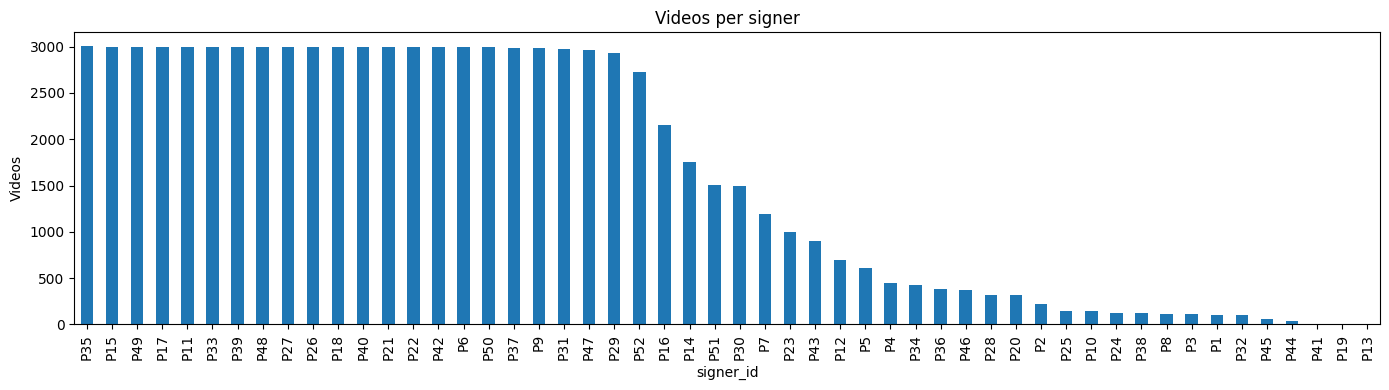

In [15]:
duplicates = df[
    df["video_file"].duplicated(keep=False) | df["video_id"].duplicated(keep=False)
]
print(f"Số dòng liên quan video trùng: {len(duplicates)}")
if not duplicates.empty:
    display(duplicates.head(20))
overlap = audit_metadata(df)
display(overlap)
split_summary = (
    df.groupby("split")
    .agg(
        videos=("video_id", "size"),
        glosses=("gloss", "nunique"),
        signers=("signer_id", "nunique"),
    )
    .reindex(["train", "val", "test"])
)
display(split_summary)
split_summary[["videos", "signers"]].plot.bar(
    subplots=True,
    layout=(1, 2),
    figsize=(12, 4),
    legend=False,
    title=["Videos per split", "Signers per split"],
)
plt.tight_layout()
plt.show()
signer_summary = (
    df.groupby(["split", "signer_id"]).size().rename("videos").reset_index()
)
display(signer_summary)
signer_summary.set_index("signer_id")["videos"].sort_values(ascending=False).plot.bar(
    title="Videos per signer", figsize=(14, 4)
)
plt.ylabel("Videos")
plt.tight_layout()
plt.show()

## 4. Phân bố lớp và xếp hạng ứng viên
#
Ưu tiên số video train, sau đó số người ký train; hòa điểm thì sắp gloss theo chữ để tái lập kết quả.
Số mẫu val/test chỉ dùng để báo cáo và kiểm tra độ phủ, không làm điểm xếp hạng.
Đây là **ứng viên có dữ liệu tốt**, chưa phải “10 lớp model nhận diện tốt nhất”.

,train,val,test,train_signers,total
gloss,,,,,
DOG1,24,4,17,16,45
HURDLE/TRIP1,22,3,13,18,38
DEMAND1,21,4,14,18,39
BREAKFAST1,21,3,15,17,39
BITE1,21,4,14,15,39
DARK1,21,3,15,15,39
DEAF1,20,4,15,16,39
ROCKINGCHAIR1,20,4,15,16,39
DECIDE1,20,3,15,15,38


,train,val,test,train_signers
count,2731.00,2731.00,2731.00,2731.00
mean,14.70,3.77,12.06,13.71
std,1.31,0.71,1.19,1.25
min,9.00,2.00,7.00,8.00
25%,14.00,3.00,11.00,13.00
50%,15.00,4.00,12.00,14.00
75%,15.00,4.00,13.00,15.00
max,24.00,7.00,20.00,18.00


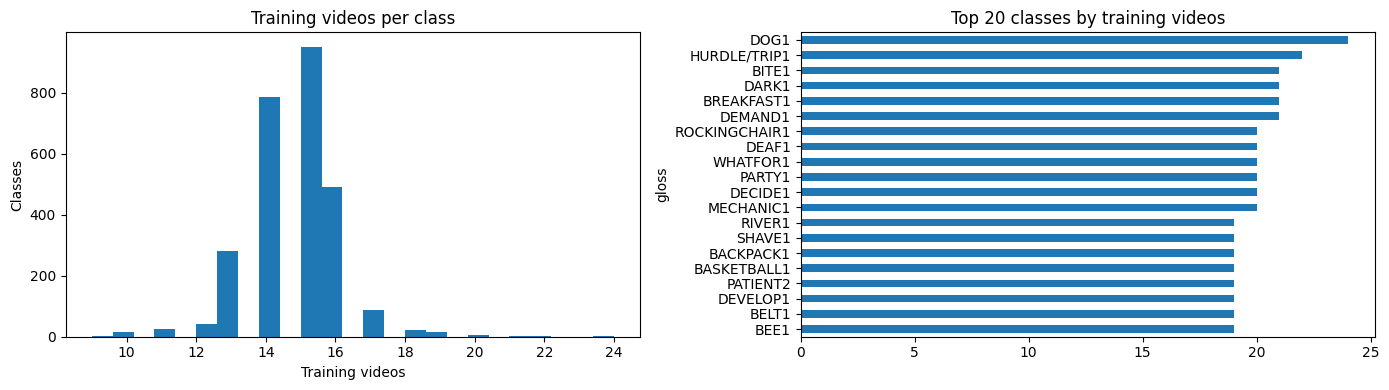

Có 2,728/2,731 lớp đạt ngưỡng train.


In [16]:
class_stats = class_statistics(df)
display(class_stats.head(30))
display(class_stats[["train", "val", "test", "train_signers"]].describe().round(2))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
class_stats["train"].plot.hist(bins=25, ax=axes[0], title="Training videos per class")
axes[0].set_xlabel("Training videos")
axes[0].set_ylabel("Classes")
class_stats.head(20)["train"].sort_values().plot.barh(
    ax=axes[1], title="Top 20 classes by training videos"
)
plt.tight_layout()
plt.show()
eligible = class_stats[
    (class_stats["train"] >= MIN_TRAIN_VIDEOS)
    & (class_stats["train_signers"] >= MIN_TRAIN_SIGNERS)
]
print(f"Có {len(eligible):,}/{len(class_stats):,} lớp đạt ngưỡng train.")

## 5. Chọn 10 lớp — giữ nguyên official splits
#
Chọn theo metadata train, rồi kiểm tra từng lớp có mẫu trong cả val và test. Không chọn theo accuracy trên test.
Một label map chung, sắp theo gloss, được dùng cho cả ba split để tránh lệch nhãn lúc train và demo.

,train,val,test,train_signers,total
gloss,,,,,
BITE1,21,4,14,15,39
BREAKFAST1,21,3,15,17,39
DARK1,21,3,15,15,39
DEAF1,20,4,15,16,39
DECIDE1,20,3,15,15,38
DEMAND1,21,4,14,18,39
DOG1,24,4,17,16,45
HURDLE/TRIP1,22,3,13,18,38
MECHANIC1,20,3,16,15,39


split,train,val,test
gloss,,,
BITE1,21,4,14
BREAKFAST1,21,3,15
DARK1,21,3,15
DEAF1,20,4,15
DECIDE1,20,3,15
DEMAND1,21,4,14
DOG1,24,4,17
HURDLE/TRIP1,22,3,13
MECHANIC1,20,3,16


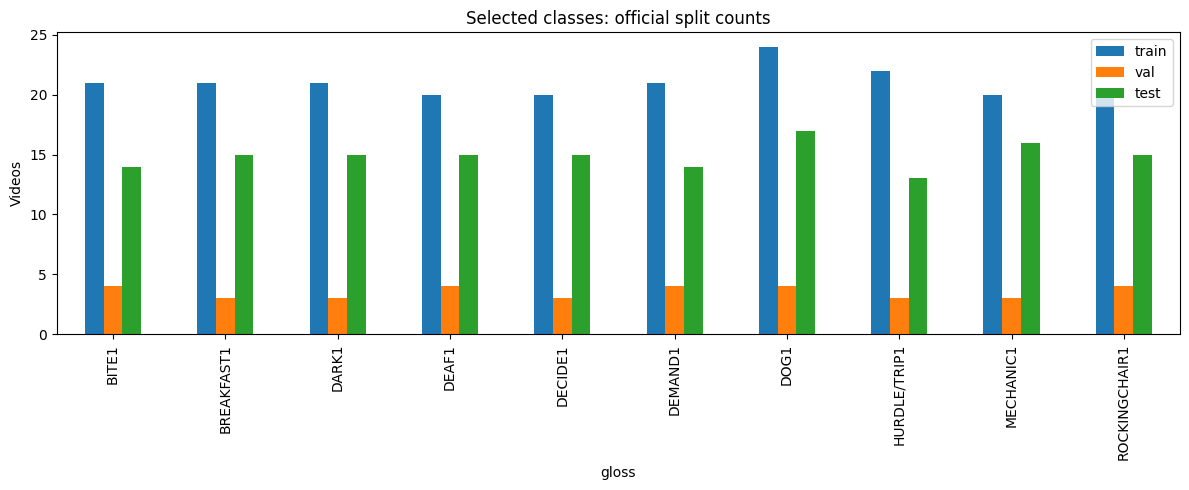

Label map: {'BITE1': 0, 'BREAKFAST1': 1, 'DARK1': 2, 'DEAF1': 3, 'DECIDE1': 4, 'DEMAND1': 5, 'DOG1': 6, 'HURDLE/TRIP1': 7, 'MECHANIC1': 8, 'ROCKINGCHAIR1': 9}
Subset: 394/83,399 video (0.47% số video).
Ước tính landmark float32 (32 frames, 2 hands, xyz): 6.06 MiB, chưa tính metadata.


In [17]:
subset, label_map = select_subset(
    df, class_stats, NUM_CLASSES, MIN_TRAIN_VIDEOS, MIN_TRAIN_SIGNERS, SELECTED_GLOSSES
)
selected_stats = class_stats.loc[list(label_map)]
display(selected_stats)
display(
    pd.crosstab(subset["gloss"], subset["split"]).reindex(
        columns=["train", "val", "test"]
    )
)
selected_stats[["train", "val", "test"]].plot.bar(
    title="Selected classes: official split counts", figsize=(12, 5)
)
plt.ylabel("Videos")
plt.tight_layout()
plt.show()
print("Label map:", label_map)
print(
    f"Subset: {len(subset):,}/{len(df):,} video ({len(subset) / len(df):.2%} số video)."
)
landmark_bytes = len(subset) * 32 * 2 * 21 * 3 * 4
print(
    f"Ước tính landmark float32 (32 frames, 2 hands, xyz): {landmark_bytes / 1024**2:.2f} MiB, chưa tính metadata."
)

## 6. Video tùy chọn: kiểm tra file và xem mẫu train
#
Mặc định bỏ qua để EDA chỉ cần metadata. Bật `CHECK_VIDEOS = True` và đặt `VIDEO_DIR` nếu video đã có sẵn.
Chỉ kiểm tra sự tồn tại/dung lượng các file trong subset; giải mã tối đa `SAMPLES_PER_CLASS` video train/lớp.
Video chưa có sẽ được báo là missing, **không bị loại khỏi CSV và không được tải tự động**.
#
Xem cả video chuyển động, không chỉ một frame, để quyết định có phù hợp demo tay hay không:
bàn tay rõ, động tác khác nhau, ít che khuất và ít phụ thuộc nét mặt/vị trí so với cơ thể.
Sau khi xem, có thể chỉnh `SELECTED_GLOSSES` ở cấu hình rồi chạy lại.

In [18]:
video_inventory = None
video_samples = pd.DataFrame()
if VIDEO_DIR is not None:
    VIDEO_DIR = Path(VIDEO_DIR).resolve()
    if not VIDEO_DIR.is_dir():
        raise FileNotFoundError(f"VIDEO_DIR không tồn tại: {VIDEO_DIR}")
    paths = [(VIDEO_DIR / filename).resolve() for filename in subset["video_file"]]
    if any(not path.is_relative_to(VIDEO_DIR) for path in paths):
        raise ValueError(
            "Đường dẫn video vượt ra ngoài VIDEO_DIR (kiểm tra symlink/metadata)."
        )
    subset["video_path"] = [str(path) for path in paths]

if CHECK_VIDEOS:
    if VIDEO_DIR is None:
        raise ValueError("Đặt VIDEO_DIR trước khi bật CHECK_VIDEOS.")
    if SAMPLES_PER_CLASS < 1:
        raise ValueError("SAMPLES_PER_CLASS phải >= 1.")
    records = []
    for row in subset.itertuples(index=False):
        path = Path(row.video_path)
        exists = path.is_file()
        records.append(
            {
                "video_id": row.video_id,
                "gloss": row.gloss,
                "split": row.split,
                "video_path": str(path),
                "exists": exists,
                "size_bytes": path.stat().st_size if exists else 0,
            }
        )
    video_inventory = pd.DataFrame(records)
    print(f"Video có sẵn: {video_inventory['exists'].sum()}/{len(video_inventory)}")
    display(video_inventory.groupby(["gloss", "split"])["exists"].agg(["sum", "count"]))
    print(
        f"Dung lượng file đã có trong subset: {video_inventory['size_bytes'].sum() / 1024**2:.2f} MiB"
    )
    display(video_inventory[~video_inventory["exists"]].head(20))

    import cv2
    from IPython.display import Video

    available = video_inventory[
        (video_inventory["split"] == "train") & video_inventory["exists"]
    ]
    sample_records = []
    for gloss, group in available.groupby("gloss", sort=True):
        for row in group.sample(
            n=min(SAMPLES_PER_CLASS, len(group)), random_state=SEED
        ).itertuples(index=False):
            capture = cv2.VideoCapture(row.video_path)
            try:
                fps = capture.get(cv2.CAP_PROP_FPS)
                frames = capture.get(cv2.CAP_PROP_FRAME_COUNT)
                width = capture.get(cv2.CAP_PROP_FRAME_WIDTH)
                height = capture.get(cv2.CAP_PROP_FRAME_HEIGHT)
                first_ok, _ = capture.read()
                capture.set(cv2.CAP_PROP_POS_FRAMES, max(0, int(frames // 2)))
                middle_ok, frame = capture.read()
                readable = bool(
                    first_ok
                    and middle_ok
                    and np.isfinite(fps)
                    and fps > 0
                    and frames > 0
                    and width > 0
                    and height > 0
                )
                sample_records.append(
                    {
                        "video_id": row.video_id,
                        "gloss": gloss,
                        "fps": fps,
                        "frames": frames,
                        "width": width,
                        "height": height,
                        "duration_seconds": frames / fps if fps > 0 else np.nan,
                        "readable_sample": readable,
                    }
                )
                if readable:
                    plt.figure(figsize=(5, 3))
                    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                    plt.title(f"{gloss} | {row.video_id}")
                    plt.axis("off")
                    plt.show()
                    display(Video(row.video_path, embed=True, width=360))
                else:
                    print(f"Không đọc được frame/FPS: {row.video_path}")
            finally:
                capture.release()
    video_samples = pd.DataFrame(sample_records)
    display(video_samples)
    if not video_samples.empty:
        display(
            video_samples[["duration_seconds", "fps", "width", "height"]].describe()
        )
else:
    print(
        "Bỏ qua kiểm tra video; kết quả EDA hiện dựa trên metadata, chưa xác nhận chất lượng hình ảnh."
    )

Bỏ qua kiểm tra video; kết quả EDA hiện dựa trên metadata, chưa xác nhận chất lượng hình ảnh.


## 7. Xuất kết quả cho Notebook 02
#
Ghi vào thư mục output riêng; không sửa metadata nguồn hoặc `data/splits` của repo.
Chạy lại sẽ cập nhật file output cùng tên. Trên Kaggle, lưu phiên bản notebook có outputs trước khi kết thúc phiên.
#
- `train.csv`, `val.csv`, `test.csv`: giữ split/người ký, thêm `video_id`, `class_id`; giữ `video_file` để ghép với thư mục video.
- `label_map.json`: gloss → class ID cố định. Nếu có `video_path`, đó là đường dẫn của phiên hiện tại;
  chuyển máy thì dùng `video_file` với thư mục video mới.
- `class_statistics.csv`, `selected_classes.csv`, `split_summary.csv`, `signer_summary.csv`, `signer_overlap.csv`: bảng cho báo cáo.
- Khi bật video: `video_inventory.csv`, `video_samples.csv` và `missing_videos.csv` để chuẩn bị subset.
#
File `summary.json` ghi cấu hình, đường dẫn nguồn, số mẫu thực tế và việc đã kiểm tra video hay chưa.
**Subset CSV là danh sách cần xử lý, chưa phải tập video đã được tải/giải nén.**

In [19]:
export_subset(subset, class_stats, label_map, OUTPUT_DIR)
split_summary.to_csv(OUTPUT_DIR / "split_summary.csv")
signer_summary.to_csv(OUTPUT_DIR / "signer_summary.csv", index=False)
overlap.to_csv(OUTPUT_DIR / "signer_overlap.csv", index=False)
if video_inventory is not None:
    video_inventory.to_csv(OUTPUT_DIR / "video_inventory.csv", index=False)
    video_inventory[~video_inventory["exists"]].to_csv(
        OUTPUT_DIR / "missing_videos.csv", index=False
    )
    video_samples.to_csv(OUTPUT_DIR / "video_samples.csv", index=False)
else:
    # Remove only stale reports from a previous run with video checks enabled.
    for name in ("video_inventory.csv", "missing_videos.csv", "video_samples.csv"):
        (OUTPUT_DIR / name).unlink(missing_ok=True)
summary = {
    "dataset": "ASL Citizen",
    "split_dir": str(SPLIT_DIR.resolve()),
    "video_dir": str(VIDEO_DIR) if VIDEO_DIR is not None else None,
    "source_videos": len(df),
    "source_classes": int(df["gloss"].nunique()),
    "source_signers": int(df["signer_id"].nunique()),
    "selected_classes": list(label_map),
    "selected_videos": len(subset),
    "selected_split_counts": subset["split"].value_counts().to_dict(),
    "min_train_videos": MIN_TRAIN_VIDEOS,
    "min_train_signers": MIN_TRAIN_SIGNERS,
    "selection": "manual"
    if SELECTED_GLOSSES
    else "training video count, training signer count, gloss",
    "video_files_checked": video_inventory is not None,
    "seed": SEED,
    "sampled_video_count": len(video_samples),
    "available_video_count": int(video_inventory["exists"].sum())
    if video_inventory is not None
    else None,
}
(OUTPUT_DIR / "summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8"
)
print(f"Output: {OUTPUT_DIR.resolve()}")
print("\n".join(path.name for path in sorted(OUTPUT_DIR.iterdir()) if path.is_file()))

Output: /kaggle/working/asl_citizen_eda
class_statistics.csv
label_map.json
selected_classes.csv
signer_overlap.csv
signer_summary.csv
split_summary.csv
summary.json
test.csv
train.csv
val.csv


## 8. Cách viết kết luận EDA
#
Dựa vào các bảng đã chạy, nêu: số video/gloss/người ký thực tế; phân bố train/val/test;
kiểm tra không trùng người ký/video; danh sách 10 lớp và số video/người ký train mỗi lớp;
số video còn thiếu hoặc lỗi nếu đã kiểm tra. Không kết luận chất lượng video khi `CHECK_VIDEOS = False`.
#
Các lớp chọn tự động chỉ là baseline theo độ phủ dữ liệu. Chưa kiểm tra độ phân biệt của động tác,
tỷ lệ MediaPipe tìm được tay, accuracy hay khả năng từ chối ký hiệu ngoài 10 lớp.
Notebook 02 cần dùng đúng CSV subset và label map này; không tạo lại split ngẫu nhiên.